In [5]:
!pip install numpy==1.26.4
!pip install scikit-surprise --prefer-binary

In [6]:
!pip install matplotlib seaborn

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
netflix_dataset = pd.read_csv('/content/drive/MyDrive/Dataset/combined_data_1.txt',header = None, names = ['Cust_Id', 'Rating'], usecols = [0,1])
netflix_dataset

,Cust_Id,Rating
0,1:,NaN
1,1488844,3.0
2,822109,5.0
3,885013,4.0
4,30878,4.0
...,...,...
24058258,2591364,2.0
24058259,1791000,2.0
24058260,512536,5.0
24058261,988963,3.0


In [9]:
netflix_dataset.tail()

,Cust_Id,Rating
24058258,2591364,2.0
24058259,1791000,2.0
24058260,512536,5.0
24058261,988963,3.0
24058262,1704416,3.0


In [10]:
netflix_dataset.dtypes

,0
Cust_Id,object
Rating,float64


In [11]:
netflix_dataset.isnull().sum()

,0
Cust_Id,0
Rating,4499


In [12]:
movie_count=netflix_dataset.isnull().sum()
movie_count=movie_count["Rating"]
movie_count

4499

In [13]:
customer_count=netflix_dataset['Cust_Id'].nunique()

In [14]:
customer_count

475257

In [15]:
customer_count - movie_count

470758

In [16]:
rating_count=netflix_dataset['Cust_Id'].count()-movie_count
rating_count

24053764

In [17]:
stars=netflix_dataset.groupby('Rating')['Rating'].agg(['count'])

In [18]:
stars

,count
Rating,
1.0,1118186
2.0,2439073
3.0,6904181
4.0,8085741
5.0,5506583


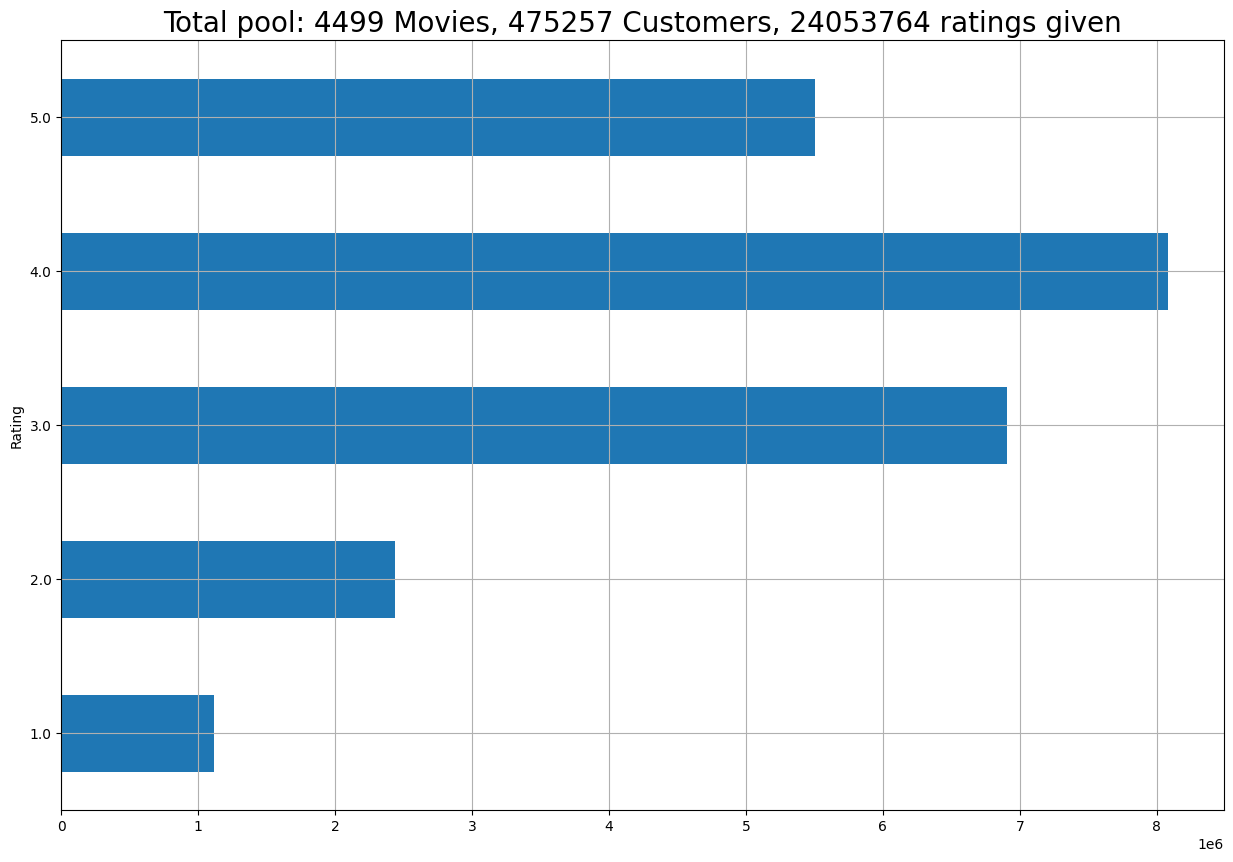

In [19]:
ax=stars.plot(kind='barh', legend=False, figsize=(15,10))

plt.title(f'Total pool: {movie_count} Movies, {customer_count} Customers, {rating_count} ratings given', fontsize=20)
plt.grid(True)

In [20]:
netflix_dataset

,Cust_Id,Rating
0,1:,NaN
1,1488844,3.0
2,822109,5.0
3,885013,4.0
4,30878,4.0
...,...,...
24058258,2591364,2.0
24058259,1791000,2.0
24058260,512536,5.0
24058261,988963,3.0


In [21]:
movie_id=None
movie_np =[]
for cust_id in netflix_dataset['Cust_Id']:
    if ':' in cust_id:
      movie_id = int(cust_id.replace(':', ''))
    movie_np.append(movie_id)

In [22]:
movie_np

[1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,


In [23]:
netflix_dataset['Movie_Id'] = movie_np

In [24]:
netflix_dataset

,Cust_Id,Rating,Movie_Id
0,1:,NaN,1
1,1488844,3.0,1
2,822109,5.0,1
3,885013,4.0,1
4,30878,4.0,1
...,...,...,...
24058258,2591364,2.0,4499
24058259,1791000,2.0,4499
24058260,512536,5.0,4499
24058261,988963,3.0,4499


In [25]:
netflix_dataset = netflix_dataset[netflix_dataset['Rating'].notna()]

In [26]:
netflix_dataset

,Cust_Id,Rating,Movie_Id
1,1488844,3.0,1
2,822109,5.0,1
3,885013,4.0,1
4,30878,4.0,1
5,823519,3.0,1
...,...,...,...
24058258,2591364,2.0,4499
24058259,1791000,2.0,4499
24058260,512536,5.0,4499
24058261,988963,3.0,4499


In [27]:
netflix_dataset.info()

<class 'pandas.core.frame.DataFrame'>
Index: 24053764 entries, 1 to 24058262
Data columns (total 3 columns):
 #   Column    Dtype  
---  ------    -----  
 0   Cust_Id   object 
 1   Rating    float64
 2   Movie_Id  int64  
dtypes: float64(1), int64(1), object(1)
memory usage: 734.1+ MB


In [28]:
netflix_dataset["Cust_Id"]=netflix_dataset["Cust_Id"].astype(int)

/tmp/ipykernel_13942/358752458.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  netflix_dataset["Cust_Id"]=netflix_dataset["Cust_Id"].astype(int)


In [29]:
netflix_dataset.info()

<class 'pandas.core.frame.DataFrame'>
Index: 24053764 entries, 1 to 24058262
Data columns (total 3 columns):
 #   Column    Dtype  
---  ------    -----  
 0   Cust_Id   int64  
 1   Rating    float64
 2   Movie_Id  int64  
dtypes: float64(1), int64(2)
memory usage: 734.1 MB


In [30]:
dataset_movie_summary=netflix_dataset.groupby('Movie_Id')['Rating'].agg(["count"])

In [31]:
dataset_movie_summary

,count
Movie_Id,
1,547
2,145
3,2012
4,142
5,1140
...,...
4495,614
4496,9519
4497,714


In [32]:
movie_benchmark=round(dataset_movie_summary['count'].quantile(0.6),0)
movie_benchmark

908.0

In [33]:
drop_movie_list=dataset_movie_summary[dataset_movie_summary['count']<movie_benchmark].index
drop_movie_list

Index([   1,    2,    4,    7,    9,   10,   11,   12,   13,   14,
       ...
       4480, 4481, 4486, 4487, 4491, 4494, 4495, 4497, 4498, 4499],
      dtype='int64', name='Movie_Id', length=2699)

In [34]:
len(drop_movie_list)

2699

In [35]:
4499-2699

1800

In [36]:
dataset_cust_summary=netflix_dataset.groupby('Cust_Id')['Rating'].agg(["count"])
dataset_cust_summary

,count
Cust_Id,
6,153
7,195
8,21
10,49
25,4
...,...
2649404,12
2649409,10
2649421,3


In [37]:
cust_benchmark=round(dataset_cust_summary['count'].quantile(0.6),0)
cust_benchmark

36.0

In [38]:
drop_cust_list=dataset_cust_summary[dataset_cust_summary['count']<cust_benchmark].index
drop_cust_list

Index([      8,      25,      33,      83,      94,     126,     130,     133,
           142,     149,
       ...
       2649337, 2649343, 2649351, 2649376, 2649379, 2649384, 2649401, 2649404,
       2649409, 2649421],
      dtype='int64', name='Cust_Id', length=282042)

In [39]:
len(drop_cust_list)

282042

In [40]:
netflix_dataset=netflix_dataset[~netflix_dataset['Movie_Id'].isin(drop_movie_list)]
netflix_dataset=netflix_dataset[~netflix_dataset['Cust_Id'].isin(drop_cust_list)]
print('After the triming, the shape is: {}'.format(netflix_dataset.shape))

After the triming, the shape is: (19695836, 3)


In [41]:
netflix_dataset

,Cust_Id,Rating,Movie_Id
696,712664,5.0,3
697,1331154,4.0,3
698,2632461,3.0,3
699,44937,5.0,3
700,656399,4.0,3
...,...,...,...
24056842,1055714,5.0,4496
24056843,2643029,4.0,4496
24056844,267802,4.0,4496
24056845,1559566,3.0,4496


In [42]:
netflix_dataset.info()

<class 'pandas.core.frame.DataFrame'>
Index: 19695836 entries, 696 to 24056846
Data columns (total 3 columns):
 #   Column    Dtype  
---  ------    -----  
 0   Cust_Id   int64  
 1   Rating    float64
 2   Movie_Id  int64  
dtypes: float64(1), int64(2)
memory usage: 601.1 MB


In [43]:
df_title = pd.read_csv("/content/drive/MyDrive/Dataset/movie_titles _1_.csv",   encoding='latin',header=None, usecols=[0,1,2], names=['Movie_Id','Year','Name' ])

In [44]:
df_title

,Movie_Id,Year,Name
0,1,2003.0,Dinosaur Planet
1,2,2004.0,Isle of Man TT 2004 Review
2,3,1997.0,Character
3,4,1994.0,Paula Abdul's Get Up & Dance
4,5,2004.0,The Rise and Fall of ECW
...,...,...,...
17765,17766,2002.0,Where the Wild Things Are and Other Maurice Se...
17766,17767,2004.0,Fidel Castro: American Experience
17767,17768,2000.0,Epoch
17768,17769,2003.0,The Company


In [45]:
!pip install surprise

In [47]:
from surprise import Reader, Dataset, SVD
from surprise.model_selection import cross_validate

In [48]:
reader=Reader()

In [49]:
data=  Dataset.load_from_df(netflix_dataset[['Cust_Id','Movie_Id','Rating']][:100000], reader)

In [50]:
model=SVD()

In [51]:
cross_validate(model, data, measures=['RMSE'], cv=3)

{'test_rmse': array([1.01907272, 1.02344346, 1.01497885]),
 'fit_time': (2.535022735595703, 1.4057633876800537, 2.2099294662475586),
 'test_time': (0.41530513763427734, 0.412977933883667, 0.8699753284454346)}

In [52]:
netflix_dataset

,Cust_Id,Rating,Movie_Id
696,712664,5.0,3
697,1331154,4.0,3
698,2632461,3.0,3
699,44937,5.0,3
700,656399,4.0,3
...,...,...,...
24056842,1055714,5.0,4496
24056843,2643029,4.0,4496
24056844,267802,4.0,4496
24056845,1559566,3.0,4496


In [53]:
df_title

,Movie_Id,Year,Name
0,1,2003.0,Dinosaur Planet
1,2,2004.0,Isle of Man TT 2004 Review
2,3,1997.0,Character
3,4,1994.0,Paula Abdul's Get Up & Dance
4,5,2004.0,The Rise and Fall of ECW
...,...,...,...
17765,17766,2002.0,Where the Wild Things Are and Other Maurice Se...
17766,17767,2004.0,Fidel Castro: American Experience
17767,17768,2000.0,Epoch
17768,17769,2003.0,The Company


In [54]:
user_ratings = netflix_dataset[netflix_dataset['Cust_Id'] == 1331154]
user_ratings

,Cust_Id,Rating,Movie_Id
697,1331154,4.0,3
5178,1331154,4.0,8
31460,1331154,3.0,18
92840,1331154,4.0,30
224761,1331154,3.0,44
...,...,...,...
23439584,1331154,4.0,4389
23546489,1331154,2.0,4402
23649431,1331154,4.0,4432
23844441,1331154,3.0,4472


In [55]:
movies_rated_by_user = user_ratings['Movie_Id'].nunique()

print(f"User 1331154 has rated {movies_rated_by_user} unique movies.")

User 1331154 has rated 253 unique movies.


In [56]:
copy_data_for_user = df_title.copy()
copy_data_for_user

,Movie_Id,Year,Name
0,1,2003.0,Dinosaur Planet
1,2,2004.0,Isle of Man TT 2004 Review
2,3,1997.0,Character
3,4,1994.0,Paula Abdul's Get Up & Dance
4,5,2004.0,The Rise and Fall of ECW
...,...,...,...
17765,17766,2002.0,Where the Wild Things Are and Other Maurice Se...
17766,17767,2004.0,Fidel Castro: American Experience
17767,17768,2000.0,Epoch
17768,17769,2003.0,The Company


In [57]:
CLEAN_copy_data_for_user = copy_data_for_user[~copy_data_for_user['Movie_Id'].isin(drop_movie_list)]
CLEAN_copy_data_for_user

,Movie_Id,Year,Name
2,3,1997.0,Character
4,5,2004.0,The Rise and Fall of ECW
5,6,1997.0,Sick
7,8,2004.0,What the #$*! Do We Know!?
15,16,1996.0,Screamers
...,...,...,...
17765,17766,2002.0,Where the Wild Things Are and Other Maurice Se...
17766,17767,2004.0,Fidel Castro: American Experience
17767,17768,2000.0,Epoch
17768,17769,2003.0,The Company


In [58]:
CLEAN_copy_data_for_user['Estimate_Score']=CLEAN_copy_data_for_user['Movie_Id'].apply(lambda x: model.predict(1331154, x).est)

/tmp/ipykernel_13942/3080684513.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  CLEAN_copy_data_for_user['Estimate_Score']=CLEAN_copy_data_for_user['Movie_Id'].apply(lambda x: model.predict(1331154, x).est)


In [59]:
CLEAN_copy_data_for_user

,Movie_Id,Year,Name,Estimate_Score
2,3,1997.0,Character,3.833755
4,5,2004.0,The Rise and Fall of ECW,4.048960
5,6,1997.0,Sick,3.053761
7,8,2004.0,What the #$*! Do We Know!?,3.264639
15,16,1996.0,Screamers,3.165864
...,...,...,...,...
17765,17766,2002.0,Where the Wild Things Are and Other Maurice Se...,3.608601
17766,17767,2004.0,Fidel Castro: American Experience,3.608601
17767,17768,2000.0,Epoch,3.608601
17768,17769,2003.0,The Company,3.608601


In [61]:
CLEAN_copy_data_for_user.sort_values('Estimate_Score', ascending=False)

,Movie_Id,Year,Name,Estimate_Score
24,25,1997.0,Inspector Morse 31: Death Is Now My Neighbour,4.222668
4,5,2004.0,The Rise and Fall of ECW,4.048960
17,18,1994.0,Immortal Beloved,3.882397
2,3,1997.0,Character,3.833755
29,30,2003.0,Something's Gotta Give,3.829363
...,...,...,...,...
15,16,1996.0,Screamers,3.165864
23,24,1981.0,My Bloody Valentine,3.076987
5,6,1997.0,Sick,3.053761
25,26,2004.0,Never Die Alone,2.798440


In [62]:
top5_movies=CLEAN_copy_data_for_user.sort_values('Estimate_Score', ascending=False).head(5)

In [63]:
top5_movies

,Movie_Id,Year,Name,Estimate_Score
24,25,1997.0,Inspector Morse 31: Death Is Now My Neighbour,4.222668
4,5,2004.0,The Rise and Fall of ECW,4.048960
17,18,1994.0,Immortal Beloved,3.882397
2,3,1997.0,Character,3.833755
29,30,2003.0,Something's Gotta Give,3.829363
